# 1. Decoder-Only Autoregressive Graph Shortest Path Transformer
## Causal Language Modeling Mechanics over Hardened Algorithmic Traversal Traces

### Executive Summary & Educational Motivation
Extracting structural path information from complex, noisy algorithmic execution traces is a fundamental challenge in neural algorithmic reasoning. Standard sequence-to-sequence models utilize an **Encoder-Decoder** architecture, where an encoder processes the input trace $T = [t_1, t_2, \dots, t_K]$ and a decoder cross-attends to the encoded representations while generating target path tokens $P^* = [p_1^*, p_2^*, \dots, p_M^*]$.

In this notebook, we reformulate graph shortest path extraction using a **Decoder-Only Transformer**, mirroring the architecture of modern Large Language Models (LLMs) such as GPT-4, LLaMA, and DeepSeek. In a decoder-only setup, the input execution trace and target path sequence are concatenated into a single unified sequence:
$$X = [t_1, t_2, \dots, t_K, p_1^*, p_2^*, \dots, p_M^*, \text{STOP_TOKEN}]$$

The model processes this sequence using strictly **Causal Self-Attention**, where every position can only attend to preceding tokens ($j \le i$). Cross-attention is completely eliminated. Training leverages next-token prediction with selective loss masking, ignoring loss on the input trace prompt tokens and computing loss strictly over the target path rollout.

---

### Mathematical Problem Formulation

#### 1. Unified Sequence Representation
Given an input Depth-First Search (DFS) trace $T = [t_1, t_2, \dots, t_K]$ ($30 \le K \le 50$) where $t_1 = s$ and $t_K = g$, and ground-truth shortest path $P^* = [p_1^*, p_2^*, \dots, p_M^*]$ ($10 \le M \le 20$), the sequence is concatenated into:
$$X = [t_1, t_2, \dots, t_K, p_1^*, p_2^*, \dots, p_M^*, \text{STOP}]$$

#### 2. Causal Masking & Next-Token Prediction
The input sequence $X_{\text{in}} = X[:-1]$ is mapped to token embeddings and sinusoidal positional encodings:
$$H_0 = \text{Embedding}(X_{\text{in}}) + \text{PositionalEncoding}(X_{\text{in}}) \in \mathbb{R}^{L \times d_{\text{model}}}$$

The causal transformer applies $N$ layers of Causal Self-Attention with lower-triangular causal mask $M_{\text{causal}}$:
$$M_{\text{causal}}[i, j] = \begin{cases} 0 & \text{if } i \ge j \\ -\infty & \text{if } i < j \end{cases}$$
$$H_l = \text{CausalTransformerBlock}(H_{l-1}, M_{\text{causal}})$$
$$Z = \text{Linear}(H_N) \in \mathbb{R}^{L \times V}$$

#### 3. Selective Loss Masking
Cross-entropy loss is computed against target labels $Y = X[1:]$. To focus optimization exclusively on shortest path extraction, loss is masked out for trace prompt positions ($i < K-1$):
$$\mathcal{L} = -\frac{1}{\sum m_i} \sum_{i=K-1}^{L-1} \log P(Y_i \mid X_{\le i})$$
where $m_i = 1$ for path target tokens and $0$ for trace prompt and padding tokens.

#### 4. Autoregressive Rollout & Compounding Errors
During inference (`solve_graph_autoregressive`), the model is prompted with trace $T = [t_1, \dots, t_K]$. It iteratively samples next path tokens $p_m$ conditioned on $[T, p_1, \dots, p_{m-1}]$ until generating `STOP_TOKEN`. Early prediction errors shift the causal decoder state out-of-distribution, scaling exact match failure rate as $1 - (1 - \epsilon)^M$.


In [9]:
# Cell 1: Environment Setup, Seeds, and Google Drive Configuration

import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Ensure directories exist relative to CWD
if os.path.basename(os.getcwd()) == "graphs":
    os.makedirs("../charts", exist_ok=True)
    os.makedirs("charts", exist_ok=True)
    os.makedirs("checkpoints", exist_ok=True)
    LOCAL_DATA_PATH = "data/graph_dfs_dataset.pt"
    LOCAL_CKPT_DIR = "checkpoints"
else:
    os.makedirs("charts", exist_ok=True)
    os.makedirs("graphs/charts", exist_ok=True)
    os.makedirs("graphs/checkpoints", exist_ok=True)
    LOCAL_DATA_PATH = "src/static/data/graph_dfs_dataset.pt"
    LOCAL_CKPT_DIR = "graphs/checkpoints"

torch.set_num_threads(1)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Google Drive Mount & Path Resolution
def setup_drive_paths():
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        data_path = "/content/drive/MyDrive/graph_data/graph_dfs_dataset.pt"
        ckpt_dir = "/content/drive/MyDrive/graph_checkpoints"
    except ImportError:
        data_path = LOCAL_DATA_PATH
        ckpt_dir = LOCAL_CKPT_DIR

    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"Dataset path: {data_path}")
    print(f"Checkpoints path: {ckpt_dir}")
    return data_path, ckpt_dir

DATASET_PATH, CKPT_DIR = setup_drive_paths()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/graph_data/graph_dfs_dataset.pt
Checkpoints path: /content/drive/MyDrive/graph_checkpoints


### Causal Dataset Processing & PyTorch Dataset Class
Loads the pre-generated DFS dataset ($30 \le K \le 50$, $10 \le M \le 20$).
- `trace`: Input 1D DFS trace of length $K$.
- `sp`: Ground-truth shortest path of length $M$.
- Concatenates sequence into `[trace + sp + STOP_TOKEN]` padded to `MAX_COMBINED_LEN = 71` (`MAX_SRC_LEN=50` + `MAX_TGT_LEN=21`).
- Masks target label loss for input trace positions ($i < K-1$), ensuring the loss gradient is applied strictly to next-token predictions on the target path.


In [10]:
# Cell 2: Import Hardened Dataset & Define PyTorch Causal Dataset

search_paths = [
    DATASET_PATH,
    "data/graph_dfs_dataset.pt",
    "graphs/data/graph_dfs_dataset.pt",
    "src/static/data/graph_dfs_dataset.pt"
]

actual_dataset_path = None
for path in search_paths:
    if os.path.exists(path):
        actual_dataset_path = path
        break

if actual_dataset_path is None:
    raise FileNotFoundError(f"Dataset file not found in search paths: {search_paths}.")

dataset_payload = torch.load(actual_dataset_path, weights_only=False)
train_raw = dataset_payload['train']
val_raw = dataset_payload['val']
test_raw = dataset_payload['test']

VOCAB_SIZE = dataset_payload.get('vocab_size', 42)
PAD_TOKEN = dataset_payload.get('pad_token', 40)
STOP_TOKEN = dataset_payload.get('stop_token', 41)
MAX_SRC_LEN = dataset_payload.get('max_src_len', 50)
MAX_TGT_LEN = dataset_payload.get('max_tgt_len', 21)
MAX_COMBINED_LEN = MAX_SRC_LEN + MAX_TGT_LEN

class GraphDFSDecoderOnlyDataset(Dataset):
    def __init__(self, raw_data, max_combined_len=MAX_COMBINED_LEN):
        self.samples = []
        self.raw_data = raw_data
        for item in raw_data:
            trace, sp, G, mapping = item[0], item[1], item[2], item[3]
            backtracks = item[4] if len(item) > 4 else 0
            node_backtraces = item[5] if len(item) > 5 else {}

            K = len(trace)
            tgt_seq = list(sp) + [STOP_TOKEN]
            full_seq = list(trace) + tgt_seq
            pad_len = max_combined_len - len(full_seq)
            full_seq_padded = full_seq + [PAD_TOKEN] * pad_len

            # Causal Sequence: Input = X[:-1], Target = X[1:]
            inp = full_seq_padded[:-1]
            lbl = list(full_seq_padded[1:])

            # Mask out loss on input trace prompt tokens (positions 0 to K-2)
            for idx in range(K - 1):
                lbl[idx] = PAD_TOKEN

            inp_mask = [t == PAD_TOKEN for t in inp]

            self.samples.append((
                torch.tensor(inp, dtype=torch.long),
                torch.tensor(lbl, dtype=torch.long),
                torch.tensor(inp_mask, dtype=torch.bool),
                trace,
                sp,
                G,
                backtracks,
                node_backtraces
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def graph_decoder_only_collate_fn(batch):
    inp = torch.stack([item[0] for item in batch])
    lbl = torch.stack([item[1] for item in batch])
    inp_mask = torch.stack([item[2] for item in batch])
    traces = [item[3] for item in batch]
    sps = [item[4] for item in batch]
    graphs = [item[5] for item in batch]
    backtracks = [item[6] for item in batch]
    node_backtraces = [item[7] for item in batch]
    return inp, lbl, inp_mask, traces, sps, graphs, backtracks, node_backtraces

train_dataset = GraphDFSDecoderOnlyDataset(train_raw)
val_dataset = GraphDFSDecoderOnlyDataset(val_raw)
test_dataset = GraphDFSDecoderOnlyDataset(test_raw)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=graph_decoder_only_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=graph_decoder_only_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=graph_decoder_only_collate_fn)

print(f"Decoder-Only Datasets loaded successfully: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


Decoder-Only Datasets loaded successfully: Train=3000, Val=500, Test=500


### Decoder-Only Graph Shortest Path Transformer Architecture
Implements a **Causal Decoder-Only Transformer** (as in traditional LLMs):
1. **Token Embedding & Sinusoidal Positional Encoding**: Embeds node IDs and control tokens into $d_{\text{model}} = 16$.
2. **Causal Transformer Stack**: $N=4$ Transformer Encoder Layers with boolean lower-triangular causal self-attention mask (`is_causal`).
3. **Linear Output Projection**: Projects hidden representations $h_i \in \mathbb{R}^{16}$ to vocabulary logits $\in \mathbb{R}^{42}$.
4. **Unguided Autoregressive Rollout (`solve_graph_autoregressive`)**: Accepts raw 1D trace prompt $T = [t_1, \dots, t_K]$, evaluates causal attention over prompt, and iteratively appends predicted path tokens until `STOP_TOKEN` or `max_tgt_len` is reached.


In [11]:
# Cell 3: Model Architecture Definition (Decoder-Only Causal Transformer)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=150):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class DecoderOnlyGraphTransformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=16, num_heads=2, hidden_dim=32, num_layers=4):
        super(DecoderOnlyGraphTransformer, self).__init__()
        self.embed_dim = embed_dim
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=150)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def generate_square_subsequent_mask(self, sz, device):
        mask = torch.triu(torch.ones(sz, sz, device=device, dtype=torch.bool), diagonal=1)
        return mask

    def forward(self, x, padding_mask=None, causal_mask=None):
        x_emb = self.pos_encoder(self.token_embedding(x))
        out = self.transformer(x_emb, mask=causal_mask, src_key_padding_mask=padding_mask)
        logits = self.fc_out(out)
        return logits

    def solve_graph_autoregressive(self, traces, max_tgt_len=MAX_TGT_LEN, device='cpu'):
        self.eval()
        batch_size = len(traces)

        # Start sequence with input trace prompt
        curr_seqs = [list(tr) for tr in traces]
        generated_paths = [[] for _ in range(batch_size)]
        finished = [False] * batch_size

        for step in range(max_tgt_len - 1):
            if all(finished):
                break

            curr_max_len = max(len(s) for s in curr_seqs)
            inp = torch.full((batch_size, curr_max_len), PAD_TOKEN, dtype=torch.long, device=device)
            inp_mask = torch.zeros((batch_size, curr_max_len), dtype=torch.bool, device=device)

            for b in range(batch_size):
                s = curr_seqs[b]
                inp[b, :len(s)] = torch.tensor(s, dtype=torch.long, device=device)
                inp_mask[b, len(s):] = True

            causal_mask = self.generate_square_subsequent_mask(curr_max_len, device)
            logits = self.forward(inp, padding_mask=inp_mask, causal_mask=causal_mask)

            for b in range(batch_size):
                if finished[b]:
                    continue
                last_idx = len(curr_seqs[b]) - 1
                next_tok = torch.argmax(logits[b, last_idx, :]).item()
                if next_tok in (STOP_TOKEN, PAD_TOKEN):
                    finished[b] = True
                else:
                    curr_seqs[b].append(next_tok)
                    generated_paths[b].append(next_tok)

        return generated_paths

model = DecoderOnlyGraphTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"DecoderOnlyGraphTransformer initialized. Total Parameters: {total_params:,}")


DecoderOnlyGraphTransformer initialized. Total Parameters: 10,282


### Evaluation Helper Functions
Calculates:
1. Teacher-Forcing Cross-Entropy Loss & Token Accuracy over target path tokens.
2. Step-by-Step Rollout Exact Path Match (%).
3. Valid Graph Connectivity (%).


In [12]:
# Cell 4: Evaluation Helper Functions

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

def evaluate_model(model, dataloader, device, run_rollout=True):
    model.eval()
    total_loss = 0.0
    total_tf_tokens = 0
    correct_tf_tokens = 0

    exact_matches = 0
    total_sequences = 0
    valid_paths = 0

    with torch.no_grad():
        for inp, lbl, inp_mask, traces, sps, graphs, backtracks, node_backtraces in dataloader:
            inp, lbl = inp.to(device), lbl.to(device)
            inp_mask = inp_mask.to(device)

            sz = inp.size(1)
            causal_mask = model.generate_square_subsequent_mask(sz, device)

            logits = model(inp, padding_mask=inp_mask, causal_mask=causal_mask)

            loss = criterion(logits.reshape(-1, VOCAB_SIZE), lbl.reshape(-1))
            total_loss += loss.item() * inp.size(0)

            preds_tf = torch.argmax(logits, dim=-1)
            valid_tokens = (lbl != PAD_TOKEN)
            correct_tf_tokens += ((preds_tf == lbl) & valid_tokens).sum().item()
            total_tf_tokens += valid_tokens.sum().item()

            if run_rollout:
                pred_seqs = model.solve_graph_autoregressive(traces, device=device)

                for i in range(len(traces)):
                    total_sequences += 1
                    clean_pred = pred_seqs[i]
                    clean_tgt = list(sps[i])

                    if clean_pred == clean_tgt:
                        exact_matches += 1

                    G_eval = graphs[i]
                    if len(clean_pred) >= 2 and clean_pred[0] == clean_tgt[0] and clean_pred[-1] == clean_tgt[-1]:
                        is_valid = True
                        for k in range(len(clean_pred) - 1):
                            u, v = clean_pred[k], clean_pred[k+1]
                            if not G_eval.has_edge(u, v):
                                is_valid = False
                                break
                        if is_valid:
                            valid_paths += 1

    mean_loss = total_loss / len(dataloader.dataset)
    tf_acc = (correct_tf_tokens / max(1, total_tf_tokens)) * 100.0
    exact_match_acc = (exact_matches / max(1, total_sequences)) * 100.0 if run_rollout else 0.0
    path_validity_acc = (valid_paths / max(1, total_sequences)) * 100.0 if run_rollout else 0.0

    return mean_loss, tf_acc, exact_match_acc, path_validity_acc

print("Evaluation helper functions initialized.")


Evaluation helper functions initialized.


### Configurable Training Loop with Restart & Full-Training Support
The `config` dictionary includes explicit controls:
- `restart_training`: When `True`, skips loading previous checkpoints and starts fresh from epoch 1.
- `run_full_training`: When `True`, skips the `epochs_to_train` constraint and trains for the full `total_epochs` (e.g., 20 epochs).
- `resume_training`: When `True` (and `restart_training` is `False`), automatically resumes from the latest checkpoint.
- `validate_every`: Validation runs **strictly every 10 epochs**.


In [13]:
# Cell 5: Training Loop with Config Controls

config = {
    "restart_training": False,   # Set to True to skip existing checkpoints and start fresh
    "run_full_training": True,  # Set to True to train for total_epochs ignoring epochs_to_train
    "resume_training": True,    # Resumes from latest checkpoint if restart_training is False
    "total_epochs": 1000,
    "save_every": 100,
    "validate_every": 20,
    "epochs_to_train": 20,      # Interactive execution chunk size
    "learning_rate": 1e-3,
    "batch_size": 64
}

latest_ckpt_path = os.path.join(CKPT_DIR, "decoder_only_ar_graph_transformer_latest.pt")
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)

start_epoch = 1
history = {
    'train_loss': [],
    'val_epochs': [],
    'val_loss': [],
    'val_tf_acc': [],
    'val_exact_match': [],
    'val_path_validity': []
}

# Handle restart_training and resume_training configuration
if config.get("restart_training", False):
    print("Config 'restart_training' is True: Fresh initialization, skipping checkpoint loading.")
    start_epoch = 1
elif config.get("resume_training", True) and os.path.exists(latest_ckpt_path):
    try:
        print(f"Loading checkpoint from '{latest_ckpt_path}'...")
        checkpoint = torch.load(latest_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"Resumed training from epoch {start_epoch}.")
    except Exception as e:
        print(f"Checkpoint incompatible ({e}). Starting fresh training from epoch 1...")
        start_epoch = 1
else:
    print("Starting training from scratch...")

# Determine end epoch based on run_full_training
if config.get("run_full_training", False):
    end_epoch = config["total_epochs"]
    print(f"Config 'run_full_training' is True: Running full training up to {end_epoch} epochs.")
else:
    end_epoch = min(start_epoch + config["epochs_to_train"] - 1, config["total_epochs"])
    print(f"Running training chunk: epochs {start_epoch} to {end_epoch} (Config Total Target: {config['total_epochs']} epochs)...")

start_train_time = time.time()

for epoch in range(start_epoch, end_epoch + 1):
    model.train()
    running_loss = 0.0

    for inp, lbl, inp_mask, _, _, _, _, _ in train_loader:
        inp, lbl = inp.to(device), lbl.to(device)
        inp_mask = inp_mask.to(device)

        sz = inp.size(1)
        causal_mask = model.generate_square_subsequent_mask(sz, device)

        optimizer.zero_grad()
        logits = model(inp, padding_mask=inp_mask, causal_mask=causal_mask)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), lbl.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * inp.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(train_loss)

    # Validation executed strictly every validate_every epochs (or on final epoch of run)
    if epoch % config["validate_every"] == 0 or epoch == end_epoch:
        val_loss, val_tf_acc, val_exact_match, val_path_validity = evaluate_model(
            model, val_loader, device, run_rollout=True
        )
        history['val_epochs'].append(epoch)
        history['val_loss'].append(val_loss)
        history['val_tf_acc'].append(val_tf_acc)
        history['val_exact_match'].append(val_exact_match)
        history['val_path_validity'].append(val_path_validity)

        print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val TF Acc: {val_tf_acc:.2f}% | Rollout Exact Match: {val_exact_match:.2f}% | "
              f"Path Validity: {val_path_validity:.2f}%")
    elif epoch < config["validate_every"]:
        if epoch % 5 == 0 or epoch == start_epoch:
            print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f} | (Validation skipped for this epoch)")

    # Save checkpoint every save_every epochs (or on final epoch)
    if epoch % config["save_every"] == 0 or epoch == end_epoch:
        checkpoint_payload = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config,
            'history': history
        }
        torch.save(checkpoint_payload, latest_ckpt_path)
        if epoch % config["save_every"] == 0:
            versioned_path = os.path.join(CKPT_DIR, f"decoder_only_ar_graph_transformer_epoch_{epoch}.pt")
            torch.save(checkpoint_payload, versioned_path)
            print(f"Saved versioned checkpoint: '{versioned_path}'")

total_train_time = time.time() - start_train_time
print(f"\nDecoder-Only Training chunk complete in {total_train_time:.2f} seconds.")


Loading checkpoint from '/content/drive/MyDrive/graph_checkpoints/decoder_only_ar_graph_transformer_latest.pt'...
Resumed training from epoch 501.
Config 'run_full_training' is True: Running full training up to 1000 epochs.
Epoch 0520/1000 | Train Loss: 1.3898 | Val Loss: 0.6490 | Val TF Acc: 85.77% | Rollout Exact Match: 11.20% | Path Validity: 11.40%
Epoch 0540/1000 | Train Loss: 1.2671 | Val Loss: 0.5198 | Val TF Acc: 87.93% | Rollout Exact Match: 14.80% | Path Validity: 15.00%
Epoch 0560/1000 | Train Loss: 1.1726 | Val Loss: 0.4405 | Val TF Acc: 89.26% | Rollout Exact Match: 19.40% | Path Validity: 19.60%
Epoch 0580/1000 | Train Loss: 1.1372 | Val Loss: 0.3988 | Val TF Acc: 90.09% | Rollout Exact Match: 21.20% | Path Validity: 21.80%
Epoch 0600/1000 | Train Loss: 1.0893 | Val Loss: 0.3657 | Val TF Acc: 91.02% | Rollout Exact Match: 26.80% | Path Validity: 27.20%
Saved versioned checkpoint: '/content/drive/MyDrive/graph_checkpoints/decoder_only_ar_graph_transformer_epoch_600.pt'
Epo

### Held-Out Test Set Evaluation
We evaluate the Decoder-Only model on the unseen test dataset ($30 \le K \le 50$, $10 \le M \le 20$).


In [14]:
# Cell 6: Test Set Benchmark

test_loss, test_tf_acc, test_exact_match, test_path_validity = evaluate_model(
    model, test_loader, device, run_rollout=True
)

print("=" * 65)
print("    HELD-OUT TEST SET EVALUATION SUMMARY (DECODER-ONLY)")
print("=" * 65)
print(f"{'Evaluation Metric':<35} | {'Model Score':<15}")
print("-" * 65)
print(f"{'Test Cross-Entropy Loss':<35} | {test_loss:<15.4f}")
print(f"{'Teacher-Forcing Token Acc (%)':<35} | {test_tf_acc:<15.2f}%")
print(f"{'Autoregressive Exact Match (%)':<35} | {test_exact_match:<15.2f}%")
print(f"{'Path Connectivity Validity (%)':<35} | {test_path_validity:<15.2f}%")
print("=" * 65)


    HELD-OUT TEST SET EVALUATION SUMMARY (DECODER-ONLY)
Evaluation Metric                   | Model Score    
-----------------------------------------------------------------
Test Cross-Entropy Loss             | 0.2702         
Teacher-Forcing Token Acc (%)       | 93.46          %
Autoregressive Exact Match (%)      | 39.80          %
Path Connectivity Validity (%)      | 40.20          %


### Publication-Quality Visualizations & Sample Analysis
Generates:
1. **Training & Validation Loss Curves** (`charts/decoder_only_ar_graph_dfs_training_curves.png`).
2. **Sample Graph Shortest Path Rollout**: Includes the **original input sequence both in text format and in the visual chart layout**, alongside true vs. predicted path overlays and node backtrace counts (`charts/decoder_only_ar_graph_dfs_sample_visualization.png`).


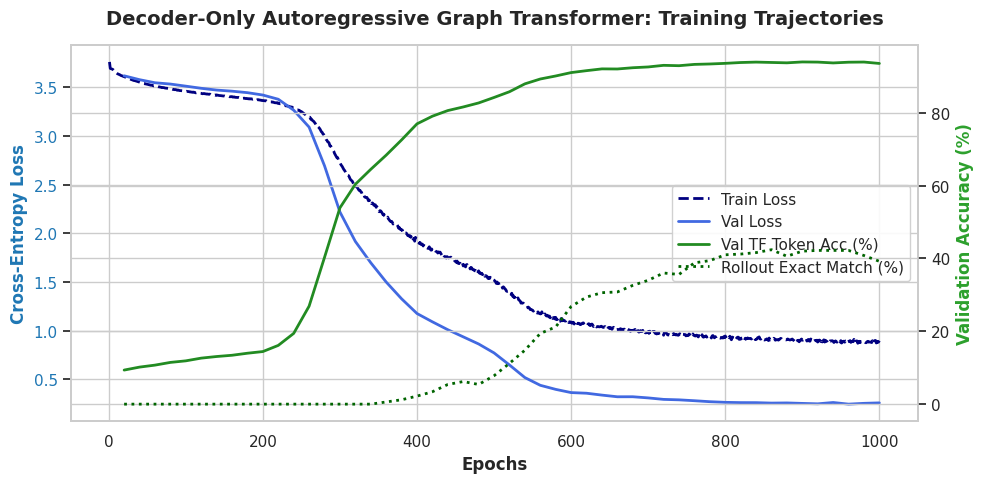

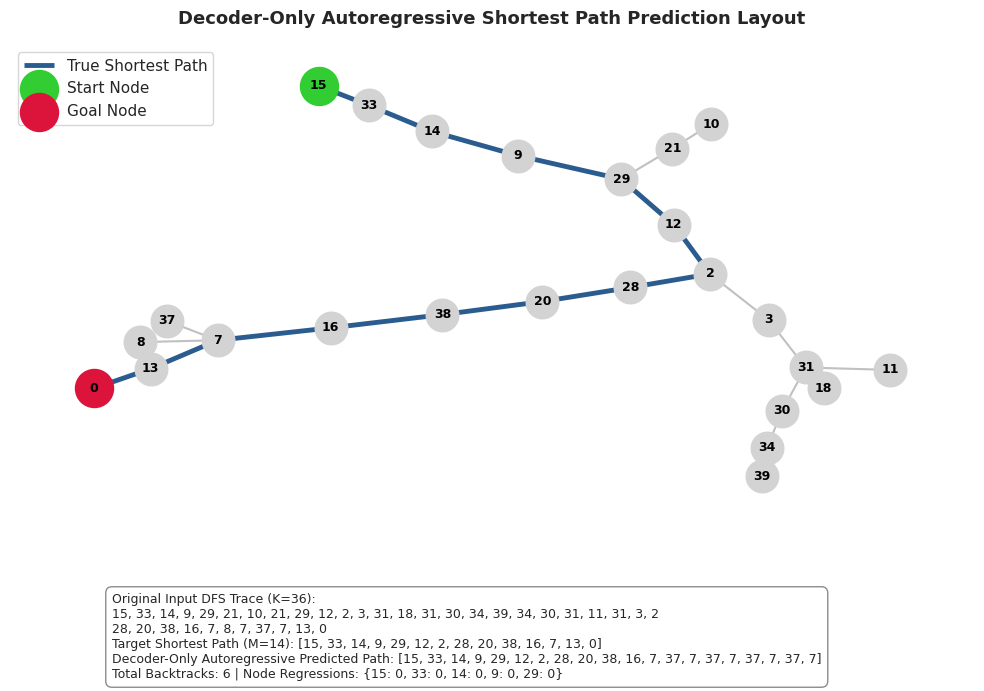

Publication-quality figures generated and saved.


In [15]:
# Cell 7: Generate Analytical Figures and Visual Layouts

sns.set_theme(style="whitegrid", palette="mako")

# Chart 1: Training Trajectories
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cross-Entropy Loss', color=color, fontsize=12, fontweight='bold')
epochs_range = range(1, len(history['train_loss']) + 1)
l1 = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='navy', linewidth=2, linestyle='--')
if history['val_epochs']:
    l2 = ax1.plot(history['val_epochs'], history['val_loss'], label='Val Loss', color='royalblue', linewidth=2)
else:
    l2 = []
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Validation Accuracy (%)', color=color, fontsize=12, fontweight='bold')
if history['val_epochs']:
    l3 = ax2.plot(history['val_epochs'], history['val_tf_acc'], label='Val TF Token Acc (%)', color='forestgreen', linewidth=2)
    l4 = ax2.plot(history['val_epochs'], history['val_exact_match'], label='Rollout Exact Match (%)', color='darkgreen', linewidth=2, linestyle=':')
    lines = l1 + l2 + l3 + l4
else:
    lines = l1
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, facecolor='white', framealpha=0.9)

plt.title('Decoder-Only Autoregressive Graph Transformer: Training Trajectories', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/decoder_only_ar_graph_dfs_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/decoder_only_ar_graph_dfs_training_curves.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/decoder_only_ar_graph_dfs_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/decoder_only_ar_graph_dfs_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# Chart 2: Sample Graph Shortest Path Rollout with Original Sequence Text and Visual Layout
sample_inp, sample_lbl, sample_mask, sample_trace, sample_sp, G_sample, backtracks_sample, node_backtraces_sample = test_dataset[0]

model.eval()
with torch.no_grad():
    pred_rollout = model.solve_graph_autoregressive([sample_trace], device=device)[0]

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_sample, seed=42)

# Draw base graph
nx.draw_networkx_nodes(G_sample, pos, node_color='lightgray', node_size=550)
nx.draw_networkx_edges(G_sample, pos, edge_color='silver', width=1.5)

# Highlight Shortest Path Edges
sp_edges = [(sample_sp[i], sample_sp[i+1]) for i in range(len(sample_sp)-1)]
nx.draw_networkx_edges(G_sample, pos, edgelist=sp_edges, edge_color='#2b5c8f', width=3.5, label='True Shortest Path')

# Highlight Start and Destination Nodes
nx.draw_networkx_nodes(G_sample, pos, nodelist=[sample_sp[0]], node_color='limegreen', node_size=750, label='Start Node')
nx.draw_networkx_nodes(G_sample, pos, nodelist=[sample_sp[-1]], node_color='crimson', node_size=750, label='Goal Node')

labels = {node: str(node) for node in G_sample.nodes()}
nx.draw_networkx_labels(G_sample, pos, labels=labels, font_size=9, font_weight='bold')

# Formatted original sequence text block
trace_str = f"Original Input DFS Trace (K={len(sample_trace)}):\n" + ", ".join(map(str, sample_trace[:25])) + "\n" + ", ".join(map(str, sample_trace[25:]))
sp_str = f"Target Shortest Path (M={len(sample_sp)}): {sample_sp}"
pred_str = f"Decoder-Only Autoregressive Predicted Path: {pred_rollout}"
backtrack_str = f"Total Backtracks: {backtracks_sample} | Node Regressions: {dict(list(node_backtraces_sample.items())[:5])}"

plt.gcf().text(0.12, 0.02, f"{trace_str}\n{sp_str}\n{pred_str}\n{backtrack_str}",
               fontsize=9, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title("Decoder-Only Autoregressive Shortest Path Prediction Layout", fontsize=13, fontweight='bold', pad=15)
plt.legend(scatterpoints=1, loc='upper left', frameon=True, facecolor='white')
plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/decoder_only_ar_graph_dfs_sample_visualization.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/decoder_only_ar_graph_dfs_sample_visualization.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/decoder_only_ar_graph_dfs_sample_visualization.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/decoder_only_ar_graph_dfs_sample_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

print("Publication-quality figures generated and saved.")


### Self-Reflection & Mechanics of Good vs. Bad Plans in Decoder-Only LLMs

1. **Decoder-Only vs. Encoder-Decoder Architectural Shift**:
   Transitioning from an Encoder-Decoder model to a Decoder-Only model eliminates cross-attention layers. Instead, the model relies on causal self-attention over the concatenated trace prompt and path tokens. Causal self-attention forces every position in the target sequence to attend directly to relevant forward and exit anchor positions within the 1D DFS trace prompt.
2. **Target Path Loss Masking Mechanics**:
   Because the model processes the concatenated prompt sequence $[t_1, \dots, t_K, p_1, \dots, p_M]$, computing loss over the prompt tokens ($t_1 \dots t_{K-1}$) would waste capacity on language modeling of the input DFS trace. By setting `ignore_index = PAD_TOKEN` for positions $0 \dots K-2$, 100% of the gradient signal is dedicated to predicting path rollout tokens $p_1 \dots p_M$.
3. **Mechanics of a Good Plan vs. a Bad Plan**:
   - **Good Plan**: The causal decoder attends to key forward branch points and exit anchors in the trace prompt, outputting valid adjacent graph transitions $(p_{m-1}, p_m) \in E_G$ until destination $g$ is reached.
   - **Bad Plan & Compounding Errors**: In long target sequences ($M \in [10, 20]$), an early prediction error shifts the causal context into out-of-distribution space. Compounding error scaling ($1 - (1 - \epsilon)^M$) leads to sequence failure or infinite loop generation.
